# 🔍 03 — Model Explainability (SHAP)

**Fraud Detection Capstone — Sprint 3: Imbalance, Tuning & Explainability**

## 🎯 Goal
Explain the tuned model's decisions with SHAP: which features drive fraud predictions globally, and why a specific transaction was flagged.


In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import shap
from pathlib import Path

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

proc_dir = Path("data/processed")
train = pd.read_csv(proc_dir / "train.csv")
val = pd.read_csv(proc_dir / "val.csv")
X_train, y_train = train.drop(columns=["Class"]), train["Class"]
X_val, y_val = val.drop(columns=["Class"]), val["Class"]

model = tf.keras.models.load_model("models/sprint3_tuned_nn.keras")
print(f"Loaded tuned model. Val shape: {X_val.shape}")


I0000 00:00:1788704497.534103    9241 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788704497.584102    9241 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1788704499.160178    9241 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Loaded tuned model. Val shape: (751, 32)


## 1. Build a SHAP Explainer

`KernelExplainer` works with any model (including this Keras network) by treating it as a black box. A small background sample keeps this fast — SHAP's cost scales with background size, not full dataset size.


In [2]:
background = X_train.sample(n=min(100, len(X_train)), random_state=SEED)
explain_sample = X_val.sample(n=min(50, len(X_val)), random_state=SEED)

def predict_fn(x):
    return model.predict(x, verbose=0).ravel()

explainer = shap.KernelExplainer(predict_fn, background)
shap_values = explainer.shap_values(explain_sample, nsamples=100)

print(f"SHAP values shape: {np.array(shap_values).shape}")


  0%|          | 0/50 [00:00<?, ?it/s]

SHAP values shape: (50, 32)


## 2. Global Feature Importance

/tmp/ipykernel_9241/2111110365.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, explain_sample, show=False)


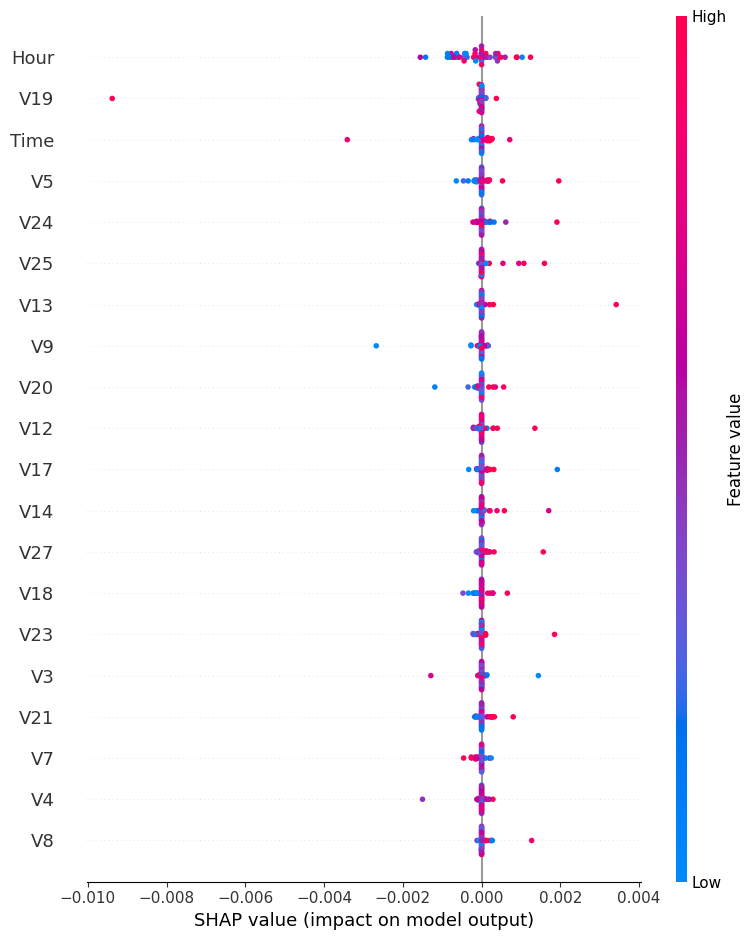

In [3]:
shap.summary_plot(shap_values, explain_sample, show=False)
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=100, bbox_inches="tight")
plt.show()


In [4]:
mean_abs_shap = pd.DataFrame({
    "feature": explain_sample.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0) if np.array(shap_values).ndim == 2 else np.abs(np.array(shap_values)).mean(axis=(0, 2)) if np.array(shap_values).ndim == 3 else None,
})
mean_abs_shap = mean_abs_shap.sort_values("mean_abs_shap", ascending=False)
mean_abs_shap.head(10)


,feature,mean_abs_shap
30,Hour,0.000446
19,V19,0.000209
0,Time,0.000146
5,V5,0.000121
24,V24,0.000100
25,V25,0.000095
13,V13,0.000090
9,V9,0.000084
20,V20,0.000081
12,V12,0.000081


## 3. Explaining a Single Prediction

Explaining row index 35 | predicted fraud probability: 0.0046 | actual label: 0


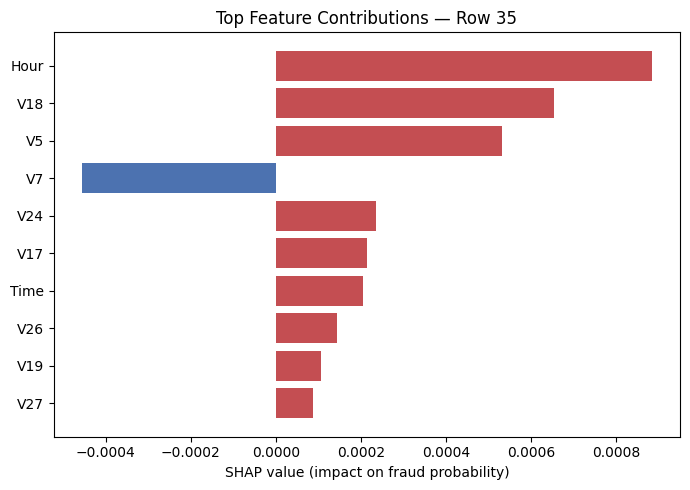

In [5]:
# Pick a transaction the model flagged as fraud (or the highest-probability one available)
sample_probs = predict_fn(explain_sample)
idx = int(np.argmax(sample_probs))
print(f"Explaining row index {idx} | predicted fraud probability: {sample_probs[idx]:.4f} | actual label: {y_val.iloc[explain_sample.index[idx]] if explain_sample.index[idx] in y_val.index else 'n/a'}")

sv = shap_values[idx] if np.array(shap_values).ndim == 2 else np.array(shap_values)[idx, :, 0]
row_shap = pd.Series(sv, index=explain_sample.columns).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
top_features = row_shap.head(10)
colors = ["#C44E52" if v > 0 else "#4C72B0" for v in top_features]
ax.barh(top_features.index[::-1], top_features.values[::-1], color=colors[::-1])
ax.set_xlabel("SHAP value (impact on fraud probability)")
ax.set_title(f"Top Feature Contributions — Row {idx}")
plt.tight_layout()
plt.show()


## 📝 Summary

The global summary plot shows which features the tuned model relies on most across many transactions; the single-prediction breakdown shows exactly why one specific transaction was flagged (or not) — the kind of evidence a fraud analyst would actually want before trusting a model's decision in production.

**Sprint 3 complete.** Carried forward to Sprint 4: the tuned model (`models/sprint3_tuned_nn.keras`), its chosen threshold, and this explainability evidence all feed into final model selection and the deployment app.
